# 수요 예측 EDA

이 노트북은 `data/DataCoSupplyChainDataset.csv`를 수요 예측과 재고 운영 관점에서 탐색합니다.

핵심 질문:
- 예측 타깃은 무엇으로 잡는 것이 좋은가?
- 상품과 카테고리별 수요는 얼마나 집중되어 있는가?
- 수요는 안정적인가, 아니면 간헐적인가?
- 뚜렷한 계절성, 요일성, 달력 효과가 있는가?
- 예측 시점에 쓸 수 있는 변수와 누수 위험 변수를 어떻게 구분할 것인가?


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Noto Sans KR', 'Malgun Gothic', 'AppleSDGothicNeoM00', 'NanumSquare Neo OTF', 'DejaVu Sans'],
    'axes.unicode_minus': False,
})

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_PATH = 'data/DataCoSupplyChainDataset.csv'
df = pd.read_csv(DATA_PATH, encoding='latin1', low_memory=False)
df['order_dt'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['ship_dt'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')
df['lead_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['order_month'] = df['order_dt'].dt.to_period('M')
df['order_day_name'] = df['order_dt'].dt.day_name()
df['order_day_num'] = df['order_dt'].dt.day
print(df.shape)


(180519, 59)


## 1. 데이터 품질과 타깃 선택

재고 수요 예측에서 가장 자연스러운 타깃은 `Order Item Quantity`입니다.
이 데이터는 거래 단위이므로 같은 상품이 여러 주문에 반복해서 등장합니다. 따라서 예측용 데이터셋을 만들기 전에 일/상품/SKU/카테고리 단위로 집계하는 과정이 필요합니다.


In [ ]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_rate': df.isna().mean(),
})
summary = summary.sort_values('missing_rate', ascending=False)
print('주문 날짜 범위:', df['order_dt'].min(), '->', df['order_dt'].max())
print('중복 행 수:', df.duplicated().sum())
print(summary.head(15).to_string())


주문 날짜 범위: 2015-01-01 00:00:00 -> 2018-01-31 23:38:00
중복 행 수: 0
                            dtype  missing_rate
Product Description       float64      1.000000
Order Zipcode             float64      0.862397
Customer Lname             object      0.000044
Customer Zipcode          float64      0.000017
Type                       object      0.000000
Product Card Id             int64      0.000000
Order Item Id               int64      0.000000
Order Item Product Price  float64      0.000000
Order Item Profit Ratio   float64      0.000000
Order Item Quantity         int64      0.000000
Sales                     float64      0.000000
Order Item Total          float64      0.000000
Order Profit Per Order    float64      0.000000
Order Region               object      0.000000
Order State                object      0.000000


count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000


<string>:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


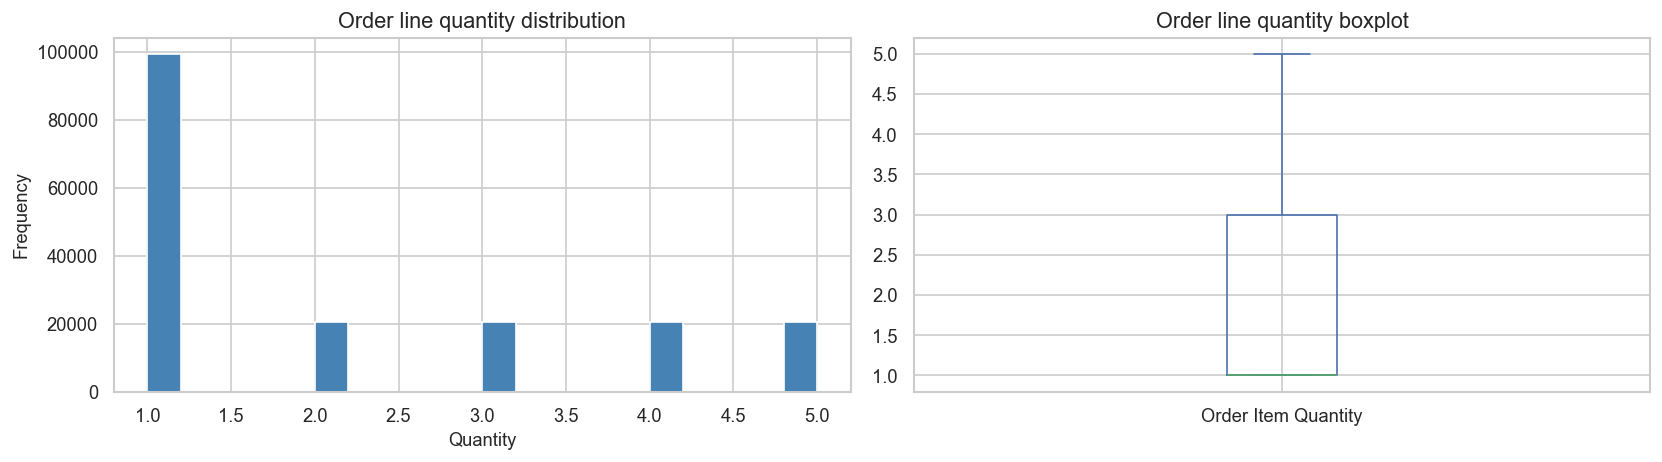

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['Order Item Quantity'].plot(kind='hist', bins=20, ax=ax[0], color='steelblue')
ax[0].set_title('Order line quantity distribution')
ax[0].set_xlabel('Quantity')

df['Order Item Quantity'].plot(kind='box', ax=ax[1])
ax[1].set_title('Order line quantity boxplot')
plt.tight_layout()
plt.show()

print(df['Order Item Quantity'].describe().to_string())


### 해석
- 라인 단위 수량은 1~3개에 강하게 몰려 있습니다.
- 그래서 원본 거래 행 자체는 예측 단위로는 약하고, 일별 SKU 또는 일별 카테고리 시계열이 훨씬 유용합니다.
- 수량이 5로 제한되어 있어 극단값은 크지 않습니다. 따라서 모델링의 큰 난점은 단일 행의 큰 스파이크보다 간헐 수요입니다.


## 2. 시계열 패턴

먼저 전체 시계열을 보고 수요가 안정적인지, 계절성이 있는지, 혹은 데이터 커버리지 문제의 영향을 받는지 확인합니다.


일별 수량 요약
count    1127.000000
mean      340.797693
std       101.537645
min        68.000000
25%       333.000000
50%       368.000000
75%       396.000000
max       509.000000
일별 주문 건수 요약
count    1127.000000
mean      160.176575
std        34.745022
min        68.000000
25%       157.000000
50%       169.000000
75%       180.000000
max       220.000000


<string>:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


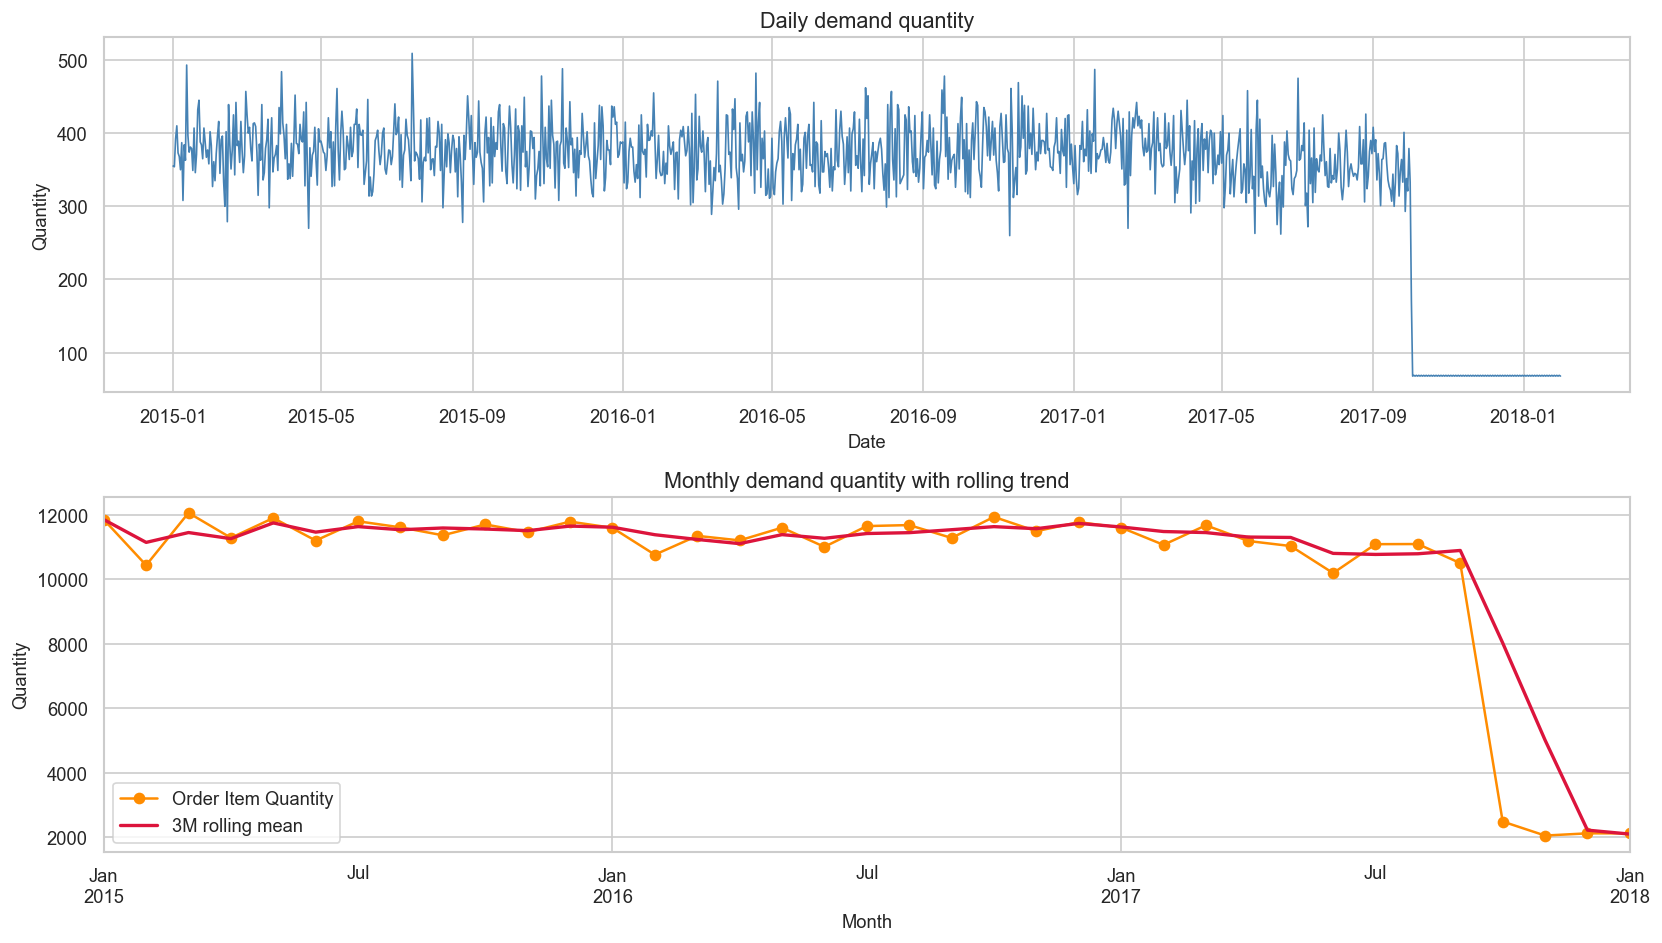

In [ ]:
daily_qty = df.groupby(df['order_dt'].dt.date)['Order Item Quantity'].sum()
daily_orders = df.groupby(df['order_dt'].dt.date).size()
monthly_qty = df.groupby(df['order_month'])['Order Item Quantity'].sum().sort_index()
monthly_orders = df.groupby(df['order_month']).size().sort_index()

print('일별 수량 요약')
print(daily_qty.describe().to_string())
print('일별 주문 건수 요약')
print(daily_orders.describe().to_string())

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
daily_qty.plot(ax=ax[0], color='steelblue', linewidth=1)
ax[0].set_title('Daily demand quantity')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Quantity')

monthly_qty_ts = monthly_qty.copy()
monthly_qty_ts.index = monthly_qty_ts.index.to_timestamp()
monthly_qty_ts.plot(ax=ax[1], marker='o', color='darkorange')
monthly_qty_ts.rolling(3, min_periods=1).mean().plot(ax=ax[1], color='crimson', linewidth=2, label='3M rolling mean')
ax[1].legend()
ax[1].set_title('Monthly demand quantity with rolling trend')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Quantity')
plt.tight_layout()
plt.show()


order_day_num
1     0.0339
18    0.0338
22    0.0336
21    0.0335
3     0.0335
25    0.0335
2     0.0333
7     0.0332
26    0.0330
16    0.0330


<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


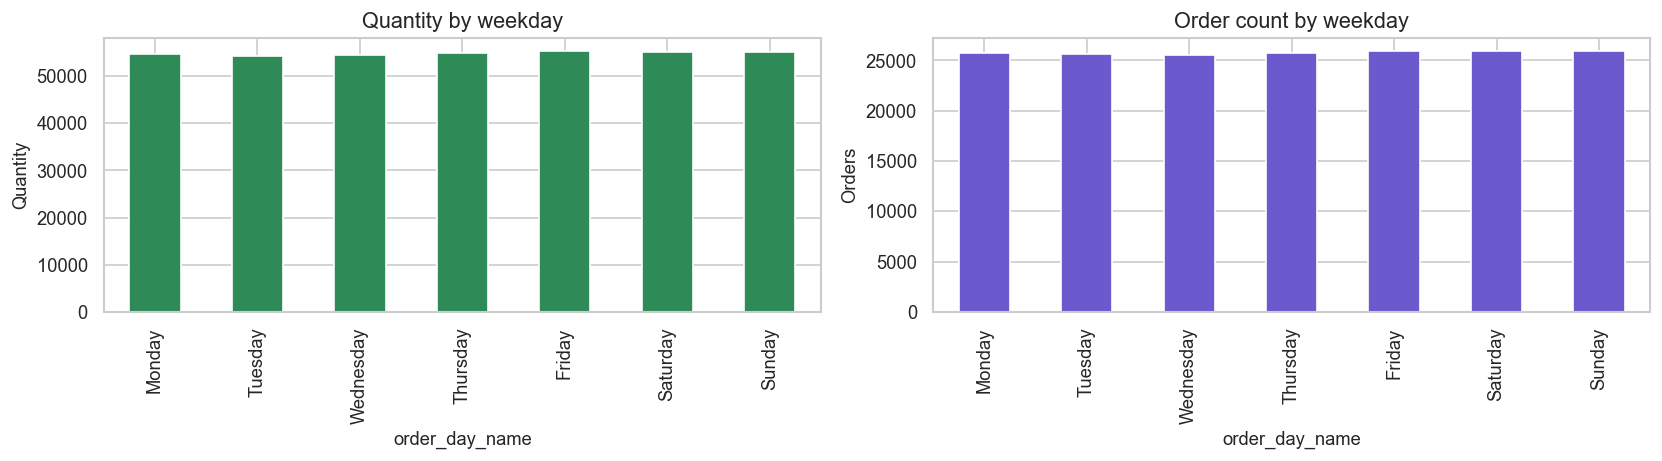

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_qty = df.groupby('order_day_name')['Order Item Quantity'].sum().reindex(weekday_order)
weekday_orders = df.groupby('order_day_name').size().reindex(weekday_order)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
weekday_qty.plot(kind='bar', ax=ax[0], color='seagreen')
ax[0].set_title('Quantity by weekday')
ax[0].set_ylabel('Quantity')

weekday_orders.plot(kind='bar', ax=ax[1], color='slateblue')
ax[1].set_title('Order count by weekday')
ax[1].set_ylabel('Orders')
plt.tight_layout()
plt.show()

day_of_month = df.groupby('order_day_num')['Order Item Quantity'].sum().sort_index()
print((day_of_month / day_of_month.sum()).sort_values(ascending=False).head(10).round(4).to_string())


### 해석
- 요일별 수요가 거의 평평해서 주간 계절성은 약합니다.
- 달력 일자 효과도 약한 편입니다.
- 월별 그래프에서 가장 눈에 띄는 것은 2017-09 이후의 급감인데, 실제 수요 붕괴보다는 부분 관측이나 수집 종료의 영향일 수 있습니다. train/test 분할 시 특히 주의가 필요합니다.


## 3. 수요 집중도와 ABC 구조

수요는 소수의 카테고리와 상품에 강하게 집중되어 있을 가능성이 큽니다. 상위 SKU가 재고 압박의 대부분을 만들기 때문에 재고 정책에서는 매우 중요한 포인트입니다.


상위 3개 카테고리 비중: 0.5064
상위 5개 카테고리 비중: 0.6895
상위 10개 카테고리 비중: 0.8933
상위 10개 상품 비중: 0.8661
{'A_상품수': 7, 'B_상품수': 38, 'C_상품수': 73}


<string>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


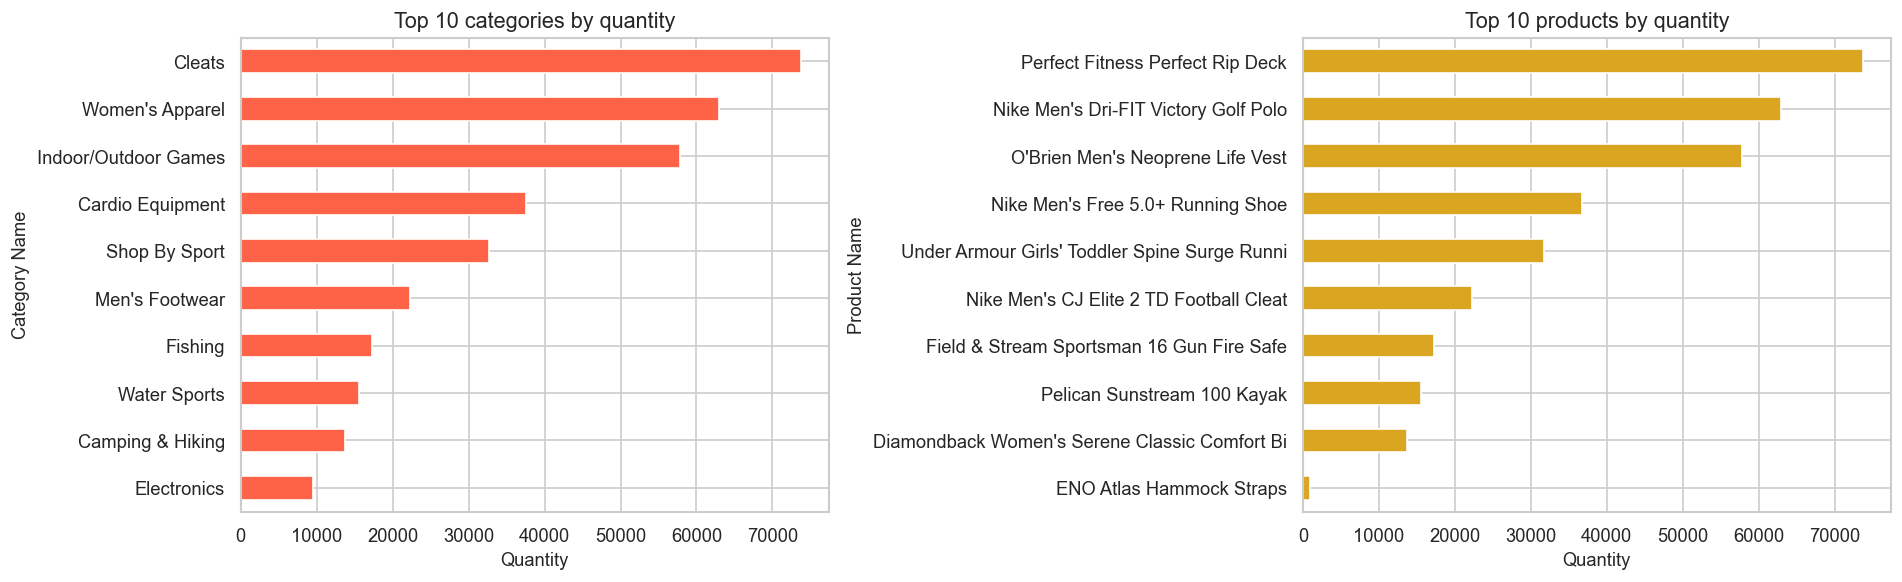

In [ ]:
cat_qty = df.groupby('Category Name')['Order Item Quantity'].sum().sort_values(ascending=False)
prod_qty = df.groupby('Product Name')['Order Item Quantity'].sum().sort_values(ascending=False)
card_qty = df.groupby('Product Card Id')['Order Item Quantity'].sum().sort_values(ascending=False)

cat_share = cat_qty / cat_qty.sum()
prod_share = prod_qty / prod_qty.sum()
card_share = card_qty / card_qty.sum()

print('상위 3개 카테고리 비중:', round(cat_share.head(3).sum(), 4))
print('상위 5개 카테고리 비중:', round(cat_share.head(5).sum(), 4))
print('상위 10개 카테고리 비중:', round(cat_share.head(10).sum(), 4))
print('상위 10개 상품 비중:', round(prod_share.head(10).sum(), 4))

abc_products = prod_share.cumsum()
a_count = (abc_products <= 0.8).sum()
b_count = ((abc_products > 0.8) & (abc_products <= 0.95)).sum()
c_count = (abc_products > 0.95).sum()
print({'A_상품수': int(a_count), 'B_상품수': int(b_count), 'C_상품수': int(c_count)})

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
cat_qty.head(10).sort_values().plot(kind='barh', ax=ax[0], color='tomato')
ax[0].set_title('Top 10 categories by quantity')
ax[0].set_xlabel('Quantity')

prod_qty.head(10).sort_values().plot(kind='barh', ax=ax[1], color='goldenrod')
ax[1].set_title('Top 10 products by quantity')
ax[1].set_xlabel('Quantity')
plt.tight_layout()
plt.show()


<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


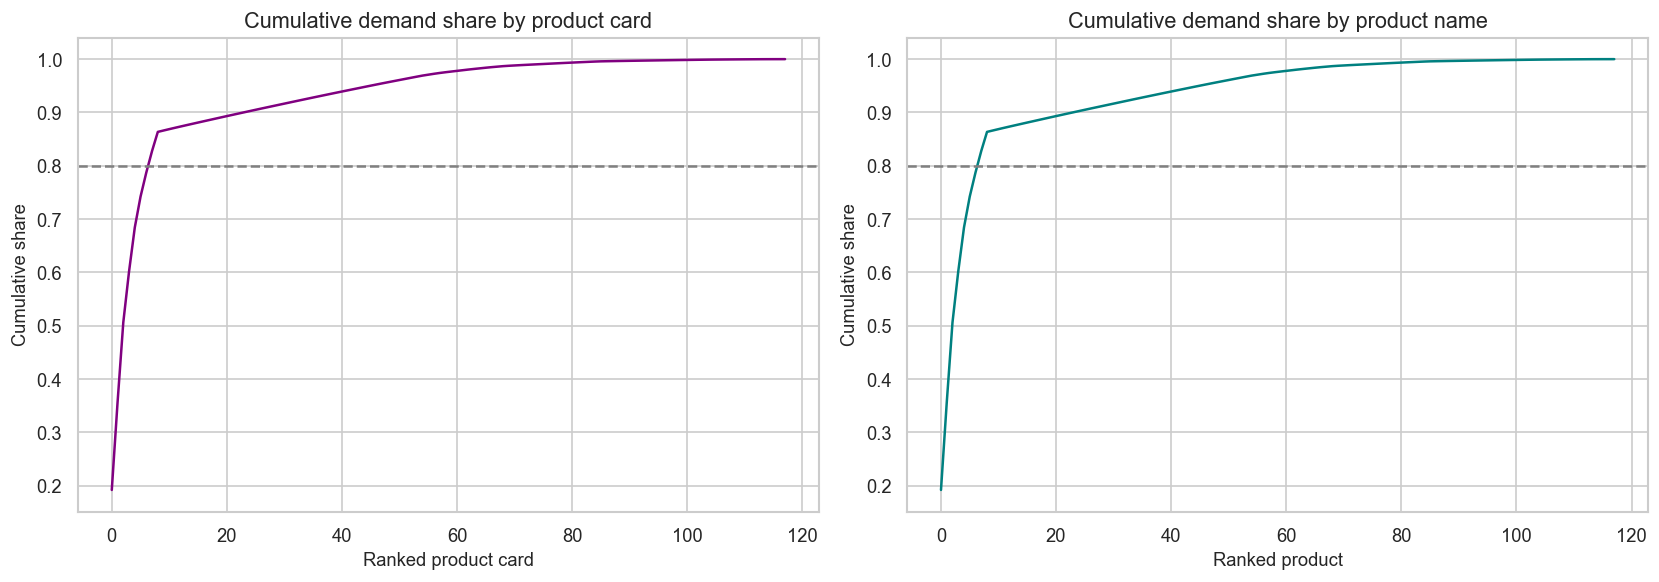

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(card_share.cumsum().values).plot(ax=ax[0], color='purple')
ax[0].axhline(0.8, linestyle='--', color='gray')
ax[0].set_title('Cumulative demand share by product card')
ax[0].set_xlabel('Ranked product card')
ax[0].set_ylabel('Cumulative share')

pd.Series(prod_share.cumsum().values).plot(ax=ax[1], color='teal')
ax[1].axhline(0.8, linestyle='--', color='gray')
ax[1].set_title('Cumulative demand share by product name')
ax[1].set_xlabel('Ranked product')
ax[1].set_ylabel('Cumulative share')
plt.tight_layout()
plt.show()


### 해석
- 수요 집중도가 매우 높습니다. 소수의 카테고리가 전체 물량 대부분을 설명합니다.
- 전형적인 ABC 패턴입니다. 아주 작은 A군이 대부분의 수요를 만들고, long tail은 개별 비중은 작지만 운영상 무시할 수는 없습니다.
- 재고 계획에서는 단일 정책보다 A-item과 꼬리 상품을 분리해서 보는 것이 더 적절합니다.


## 4. 간헐 수요와 변동성

상품의 총수요가 높아도 간헐적일 수 있습니다. 수요가 듬성듬성하거나 burst 형태면 단순 예측 모델이 자주 실패하는 지점입니다.


In [ ]:
prod_month = df.groupby(['Product Card Id', 'order_month'])['Order Item Quantity'].sum().unstack(fill_value=0)
prod_metrics = pd.DataFrame({
    'months_active': (prod_month > 0).sum(axis=1),
    'mean_month_qty': prod_month.mean(axis=1),
    'std_month_qty': prod_month.std(axis=1),
    'cv_month_qty': prod_month.std(axis=1) / prod_month.mean(axis=1).replace(0, np.nan),
    'zero_month_share': (prod_month == 0).mean(axis=1),
    'total_qty_share': df.groupby('Product Card Id')['Order Item Quantity'].sum() / df['Order Item Quantity'].sum(),
})

print(prod_metrics[['months_active', 'cv_month_qty', 'zero_month_share', 'total_qty_share']].describe().to_string())

stable = prod_metrics[(prod_metrics['months_active'] >= 6) & (prod_metrics['mean_month_qty'] > 20)].copy()
intermittent = stable.sort_values(['zero_month_share', 'cv_month_qty'], ascending=False).head(10)
volatile = stable.sort_values('cv_month_qty', ascending=False).head(10)
print('가장 간헐적인 상품')
print(intermittent.to_string())
print('가장 변동성이 큰 상품')
print(volatile.to_string())


       months_active  cv_month_qty  zero_month_share  total_qty_share
count      118.00000    118.000000        118.000000       118.000000
mean        15.40678      2.357855          0.583601         0.008475
std         12.72741      1.853429          0.343984         0.029581
min          1.00000      0.351893          0.081081         0.000026
25%          3.00000      0.696747          0.243243         0.000199
50%          6.00000      2.554680          0.837838         0.001329
75%         28.00000      3.836429          0.918919         0.002311
max         34.00000      6.082763          0.972973         0.191882
가장 간헐적인 상품
                 months_active  mean_month_qty  std_month_qty  cv_month_qty  zero_month_share  total_qty_share
Product Card Id                                                                                               
276                         28       24.837838      19.114441      0.769569          0.243243         0.002393
897                       

<string>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


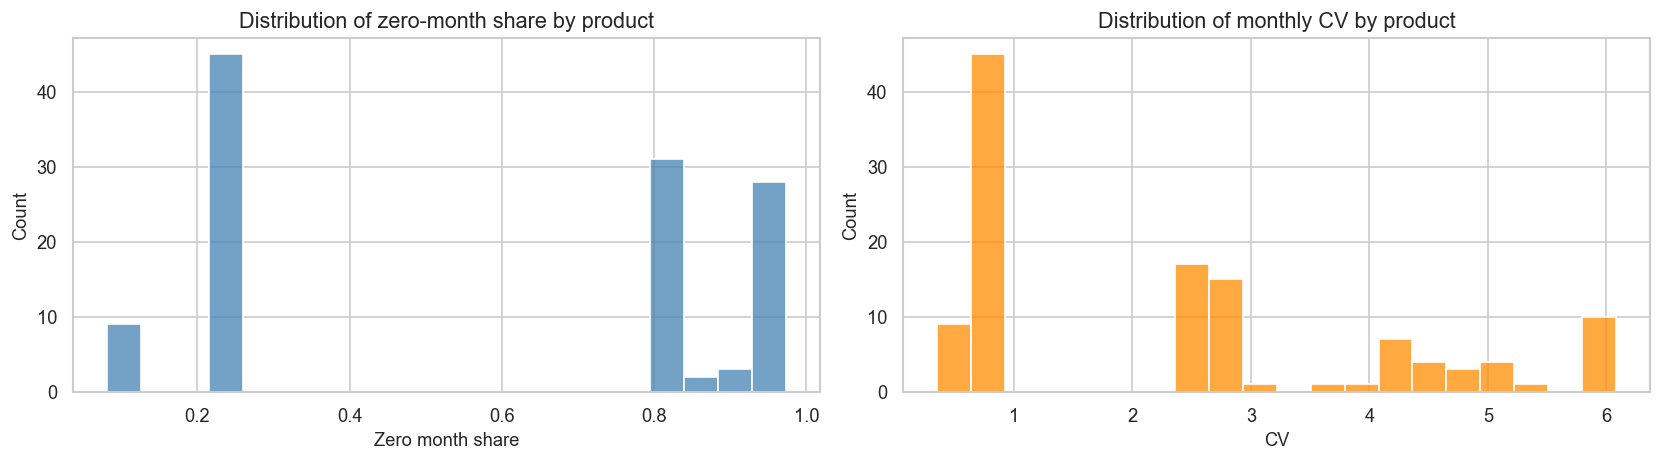

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(prod_metrics['zero_month_share'], bins=20, ax=ax[0], color='steelblue')
ax[0].set_title('Distribution of zero-month share by product')
ax[0].set_xlabel('Zero month share')

sns.histplot(prod_metrics['cv_month_qty'].replace([np.inf, -np.inf], np.nan).dropna(), bins=20, ax=ax[1], color='darkorange')
ax[1].set_title('Distribution of monthly CV by product')
ax[1].set_xlabel('CV')
plt.tight_layout()
plt.show()


                     months_active  mean_month_qty  std_month_qty  cv_month_qty
Category Name                                                                  
Cameras                          2       16.000000      94.493092      5.905818
Basketball                       2        1.810811       9.752031      5.385450
Men's Clothing                   2        5.621622      29.401768      5.230122
Garden                           2       13.081081      65.283305      4.990666
Children's Clothing              2       17.621622      87.859532      4.985894
Computers                        2       11.945946      59.086540      4.946158
Books                            2       10.945946      52.662419      4.811135
DVDs                             3       13.054054      62.430827      4.782486
Video Games                      2       22.648649     106.079691      4.683710
Music                            2       11.729730      52.637465      4.487526


<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


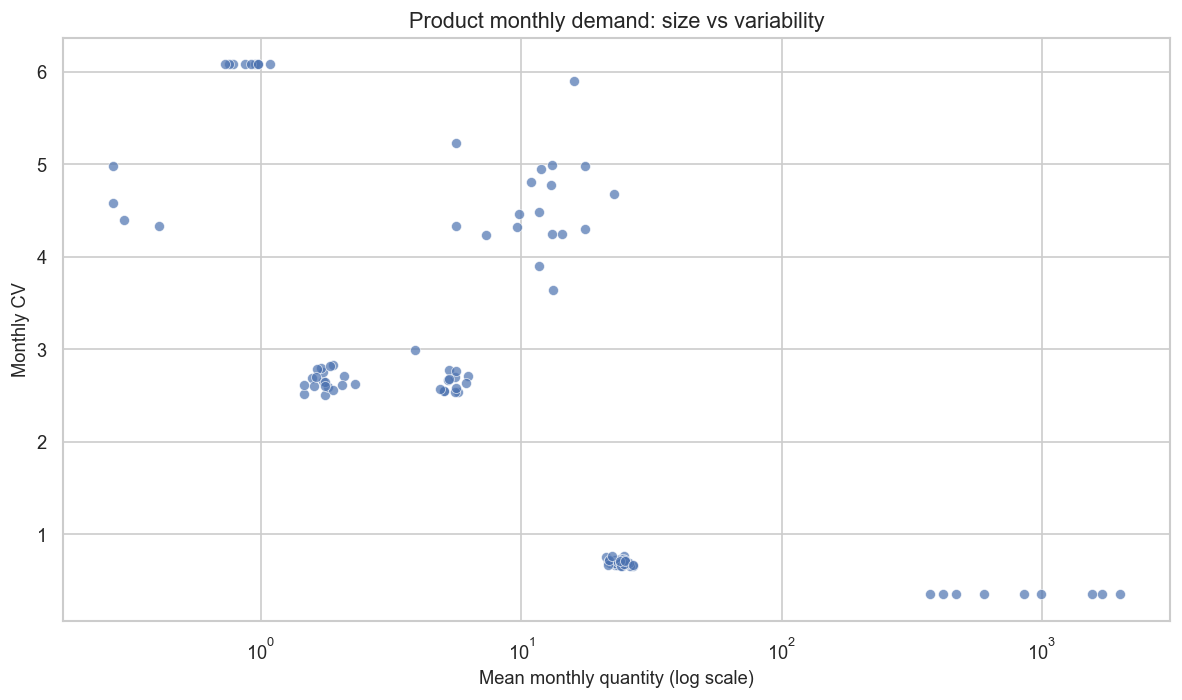

In [ ]:
cat_month = df.groupby(['Category Name', 'order_month'])['Order Item Quantity'].sum().unstack(fill_value=0)
cat_metrics = pd.DataFrame({
    'months_active': (cat_month > 0).sum(axis=1),
    'mean_month_qty': cat_month.mean(axis=1),
    'std_month_qty': cat_month.std(axis=1),
    'cv_month_qty': cat_month.std(axis=1) / cat_month.mean(axis=1).replace(0, np.nan),
})
print(cat_metrics.sort_values('cv_month_qty', ascending=False).head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=prod_metrics, x='mean_month_qty', y='cv_month_qty', alpha=0.7, ax=ax)
ax.set_xscale('log')
ax.set_title('Product monthly demand: size vs variability')
ax.set_xlabel('Mean monthly quantity (log scale)')
ax.set_ylabel('Monthly CV')
plt.tight_layout()
plt.show()


### 해석
- 많은 상품이 전체 관측 월의 일부에만 나타나므로 간헐 수요 문제가 실제로 큽니다.
- 물량이 괜찮은 상품도 CV가 높은 경우가 많아서, 시차 변수나 rolling 통계, 계층적 smoothing이 필요합니다.
- 그래서 상품 단위 예측은 집계나 추가 메타데이터 없이는 어려운 편입니다.


## 5. SKU별 무수요 비율

모델링 단위가 `SKU x day`라면, SKU마다 수요가 얼마나 자주 0이 되는지 먼저 봐야 합니다.
이 값이 높을수록 간헐 수요가 강하고, 너무 높은 SKU는 별도 처리하거나 제외 후보가 될 수 있습니다.


In [ ]:
sku_daily = pd.read_csv('data/sku_daily.csv', encoding='utf-8-sig', parse_dates=['order_date'])
sku_daily = sku_daily.sort_values(['sku_id', 'order_date']).reset_index(drop=True)

sku_grp = sku_daily.groupby('sku_id')['demand_qty']
sku_zero = pd.DataFrame({
    'total_days': sku_grp.size(),
    'zero_days': sku_grp.apply(lambda s: (s == 0).sum()),
    'active_days': sku_grp.apply(lambda s: (s > 0).sum()),
    'total_qty': sku_grp.sum(),
    'mean_qty': sku_grp.mean(),
    'std_qty': sku_grp.std(),
})
sku_zero['zero_share'] = sku_zero['zero_days'] / sku_zero['total_days']
sku_zero['active_share'] = sku_zero['active_days'] / sku_zero['total_days']
sku_zero['cv_qty'] = sku_zero['std_qty'] / sku_zero['mean_qty'].replace(0, np.nan)
sku_zero = sku_zero.sort_values(['zero_share', 'total_qty'], ascending=[False, False])

print(sku_zero[['total_days', 'zero_days', 'active_days', 'zero_share', 'active_share', 'total_qty', 'mean_qty', 'cv_qty']].describe().to_string())
print('\n무수요 비율이 높은 SKU 상위 10개')
print(sku_zero.head(10).to_string())

thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
print('\nzero_share 기준 SKU 수')
for t in thresholds:
    print(f'>= {t:.2f}: {(sku_zero["zero_share"] >= t).sum()}')


       total_days    zero_days  active_days  zero_share  active_share     total_qty    mean_qty      cv_qty
count       118.0   118.000000   118.000000  118.000000    118.000000    118.000000  118.000000  118.000000
mean       1127.0   938.245763   188.754237    0.832516      0.167484   3254.906780    2.888116    5.665483
std           0.0   257.852603   257.852603    0.228796      0.228796  11361.320818   10.081030    4.857120
min        1127.0   121.000000     3.000000    0.107365      0.002662     10.000000    0.008873    0.417812
25%        1127.0   877.000000    18.250000    0.778172      0.016193     76.250000    0.067657    2.237014
50%        1127.0  1070.000000    57.000000    0.949423      0.050577    510.500000    0.452972    4.719603
75%        1127.0  1108.750000   250.000000    0.983807      0.221828    887.750000    0.787711    8.851799
max        1127.0  1124.000000  1006.000000    0.997338      0.892635  73698.000000   65.393079   22.205453

무수요 비율이 높은 SKU 상위 10개
     

<string>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


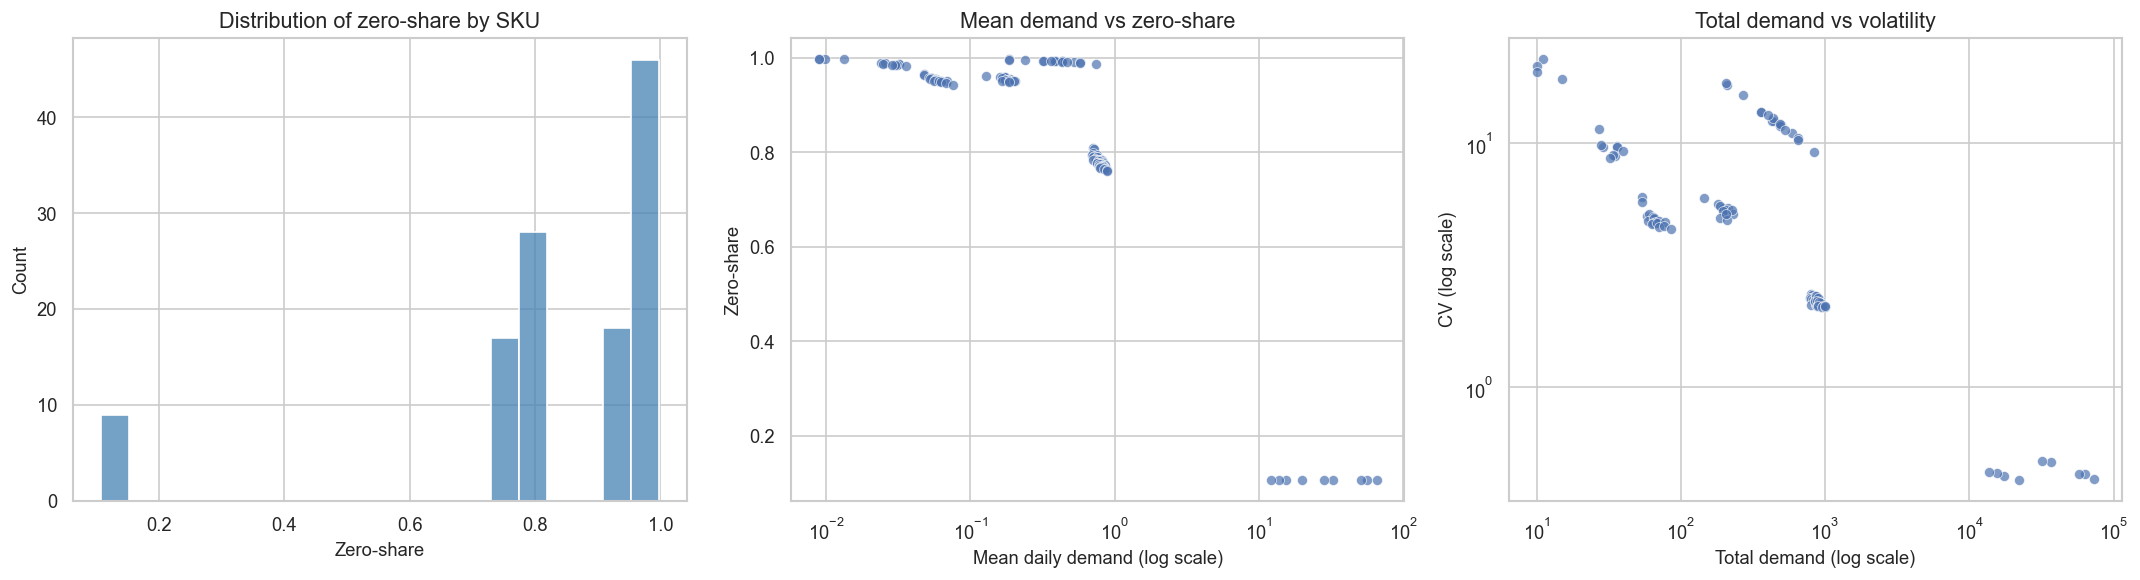

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(sku_zero['zero_share'], bins=20, ax=ax[0], color='steelblue')
ax[0].set_title('Distribution of zero-share by SKU')
ax[0].set_xlabel('Zero-share')

sns.scatterplot(data=sku_zero, x='mean_qty', y='zero_share', ax=ax[1], alpha=0.7)
ax[1].set_xscale('log')
ax[1].set_title('Mean demand vs zero-share')
ax[1].set_xlabel('Mean daily demand (log scale)')
ax[1].set_ylabel('Zero-share')

sns.scatterplot(data=sku_zero, x='total_qty', y='cv_qty', ax=ax[2], alpha=0.7)
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_title('Total demand vs volatility')
ax[2].set_xlabel('Total demand (log scale)')
ax[2].set_ylabel('CV (log scale)')
plt.tight_layout()
plt.show()


### 해석
- SKU별 0 비율이 높으면, 그 품목은 대부분의 날에 팔리지 않는다는 뜻입니다.
- 이런 SKU는 개별 예측보다 카테고리 수준으로 묶거나, 아예 별도 정책을 두는 게 더 나을 수 있습니다.
- 반대로 0 비율이 낮고 평균 수요가 있는 SKU는 30일 입력 -> 7일 출력 모델의 핵심 타깃으로 남겨둘 가치가 큽니다.
- 실무적으로는 `zero_share`와 `total_qty`를 같이 보고, 너무 희소한 SKU를 제외하거나 다른 계층으로 내리는 방식이 유용합니다.


## 6. 운영 신호와 누수 점검

배송 관련 변수는 운영 성과를 진단하는 데는 유용하지만, 사전 수요 예측을 목표로 할 때는 대부분 예측 시점에 사용할 수 없습니다.


count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
                 count      mean  median
Shipping Mode                           
First Class      27814  1.000000     1.0
Same Day          9737  0.478279     0.0
Second Class     35216  1.990828     2.0
Standard Class  107752 -0.004093     0.0
Late_delivery_risk      0      1
Shipping Mode                   
First Class         0.047  0.953
Same Day            0.543  0.457
Second Class        0.234  0.766
Standard Class      0.619  0.381


<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


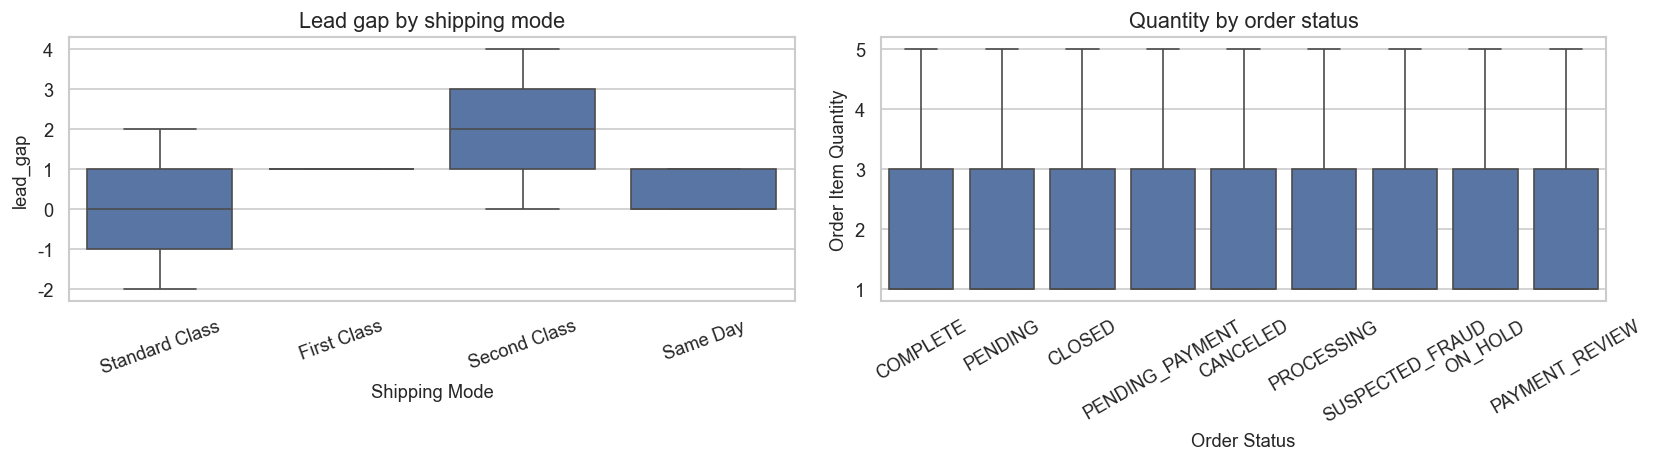

In [ ]:
lead_gap = df['lead_gap']
print(lead_gap.describe().to_string())
print(df.groupby('Shipping Mode')['lead_gap'].agg(['count', 'mean', 'median']).to_string())
print(pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'], normalize='index').round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x='Shipping Mode', y='lead_gap', ax=ax[0])
ax[0].set_title('Lead gap by shipping mode')
ax[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='Order Status', y='Order Item Quantity', ax=ax[1])
ax[1].set_title('Quantity by order status')
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
corr_cols = [
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Profit Per Order',
    'Order Item Profit Ratio',
    'Benefit per order',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk',
]
corr = df[corr_cols].corr(numeric_only=True)['Order Item Quantity'].sort_values(ascending=False)
print(corr.to_frame('수량과의 상관계수').to_string())


                               수량과의 상관계수
Order Item Quantity             1.000000
Sales                           0.106442
Order Item Total                0.105413
Order Item Discount             0.065379
Order Profit Per Order          0.015696
Benefit per order               0.015696
Order Item Profit Ratio         0.001128
Order Item Discount Rate       -0.000028
Late_delivery_risk             -0.000139
Days for shipping (real)       -0.000811
Days for shipment (scheduled)  -0.002925


## 7. 예측 시사점

모델링 전에 권장하는 설정:
- 거래 행을 일별 또는 주별 SKU 단위로 집계하기
- A-item과 중요한 카테고리부터 우선적으로 다루기
- 랜덤 분할이 아니라 시간 기준 분할 사용하기
- 사전 수요 예측에서는 누수 위험이 큰 배송 변수 제외하기
- 간헐 수요 대응을 위해 rolling mean, lag, 달력 특성 추가하기

결론적으로 이 데이터는 단일 행 예측 모델보다 계층형 수요 예측 파이프라인에 훨씬 잘 맞습니다.
